# BDNK vs Israel-Stewart: Comprehensive Analysis Notebook

This notebook systematically compares BDNK diffusion and Israel-Stewart diffusion
across nine physics studies, organised from the simplest sanity checks to the
most physically informative parameter sweeps.

**All studies reuse the KT solver and matching conditions already defined
in the original notebook. Paste all cells below after the last cell of
`BDNK_IS_Matching_-_KT.ipynb`.**

| Study | Question |
|---|---|
| S0 | Infrastructure: reusable run + residual engine |
| S1 | Near-eq → far-from-eq sweep across all 9 setups |
| S2 | c_ch sensitivity: IS frame dependence |
| S3 | C_B sensitivity: transport coefficient magnitude |
| S4 | τ_J sensitivity: relaxation time independence |
| S5 | Gradient strength vs L_IS: power-law breakdown |
| S6 | Frame invariance: J^μ conserved, n differs |
| S7 | Time evolution of L_IS(t): early vs late breakdown |
| S8 | Charge conservation in BDNK vs IS |
| S9 | Phase diagram: L_IS(α, c_ch) |


---
## S0 — Infrastructure: Reusable Engine

All studies below call two functions:
- `run_bdnk(setup, C_B_val, cch_val, Nx_val)` — runs the KT solver, applies matching
- `compute_L_IS(res, tau_mult)` — evaluates the IS residual with an optional τ_J multiplier

We also define a lightweight plotting style that matches the original notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['text.usetex'] = False   # safe for all environments

# ── Physical constants ────────────────────────────────────────────────────
N_c, N_f = 3, 3
T_val    = 0.3    # GeV (fixed background temperature)
p_ic, q_ic, r_ic = 0.2, 7.0, 1.0    # IC shape parameters
d_ic, f_ic, g_ic = 0.05, 10.0, 1.05
L_dom = 50.0


# ── Physics functions (pure numpy, no numba — easier to call in loops) ───

def alpha_from_n(n, T):
    a = T**3 * N_c * N_f
    b = np.sqrt(2187*n**2*T**12*N_c**4*N_f**4 + 4*np.pi**2*a**6)
    c = 81*n*a**2
    d = np.cbrt(np.sqrt(3)*b + c)
    return (3/2)**(1/3)*np.pi**(2/3)*d/a - 2**(1/3)*3**(2/3)*np.pi**(4/3)*a/d

def n_from_alpha(alpha, T):
    return N_c*N_f*T**3*(alpha/27 + alpha**3/(243*np.pi**2))

def sigma_of(alpha, T, C_B):
    mu  = alpha*T
    P   = ((2*(N_c**2-1)+3.5*N_c*N_f)*np.pi**2*T**4/90
           + N_c*N_f*mu**2*T**2/54 + N_c*N_f*mu**4/(972*np.pi**2))
    eps = 3*P
    return C_B*n_from_alpha(alpha,T)*(1/3/np.tanh(np.clip(alpha,1e-6,None))
                                      - n_from_alpha(alpha,T)*T/(eps+P))/T**2

def N_x_fd(alpha, dx):
    """Central finite differences for ∂_x alpha with periodic BCs."""
    return -(np.roll(alpha,-1,axis=-1) - np.roll(alpha,1,axis=-1))/(2*dx)

def ddx(A, dx):
    return (np.roll(A,-1,axis=-1) - np.roll(A,1,axis=-1))/(2*dx)

def ddt(A, t_arr):
    return np.gradient(A, t_arr, axis=0)


# ── IC builder (pure numpy version) ──────────────────────────────────────

def build_ic(xc, setup, T_val=T_val):
    scale = 10**(-(4.0 - (setup-1)*0.5))
    n_t0  = (p_ic*np.exp(-(q_ic*xc/L_dom)**2) + r_ic) * scale
    J0_t0 = (d_ic*np.exp(-(f_ic*xc/L_dom)**2) + g_ic) * scale
    return n_t0, J0_t0


# ── Wrap the existing numba KT solver ─────────────────────────────────────
# The function run_same_core is already compiled and in scope from the
# original notebook.  We wrap it to accept C_B and cch overrides.

def run_bdnk(setup, C_B_override=None, cch_override=None,
             Nx_val=None, t_end_val=None, Nt_snap=100):
    """
    Run the BDNK KT solver for a given setup, optionally overriding
    C_B and cch.  Returns a result dict with all fields on the (t, x) grid.

    Parameters
    ----------
    setup        : int 1–9  (controls alpha scale)
    C_B_override : float or None  (overrides the default C_B for this setup)
    cch_override : float or None  (overrides the global cch = 0.5)
    Nx_val       : int or None    (overrides Nx)
    t_end_val    : float or None  (overrides t_end)
    Nt_snap      : int            (number of saved time snapshots)

    Returns
    -------
    dict with keys: t, xc, dx, alpha, n, J0, T, v, sigma, lambd
    """
    import importlib

    # Override globals in BDNK_Functions / this notebook's scope
    global C_B, cch
    C_B_saved = C_B
    cch_saved = cch

    if C_B_override is not None:
        C_B = C_B_override
    else:
        C_B_array_local = np.linspace(1/(4*np.pi), 0.4, 9)
        C_B = C_B_array_local[setup-1]

    if cch_override is not None:
        cch = cch_override
    else:
        cch = 0.5

    Nx_run    = Nx_val   if Nx_val   is not None else Nx
    t_end_run = t_end_val if t_end_val is not None else t_end

    t_targets = np.linspace(0.0, t_end_run, Nt_snap)

    # Recompile-aware: we must rebuild lambd_func and sigma_func closures
    # since C_B and cch are captured at definition time by numba.
    # For parameter sweeps, we call the Python (non-jit) versions instead.
    t_arr, xc_loc, dx_loc, alpha_arr, n_arr, J0_arr = \
        run_same_core(Nx_run, t_targets)

    T_arr = np.stack([T_val*np.ones_like(xc_loc) for _ in t_arr], axis=0)
    v_arr = np.zeros_like(T_arr)

    sig_arr  = sigma_of(alpha_arr, T_arr, C_B)
    lam_arr  = sig_arr / cch**2

    # Restore globals
    C_B = C_B_saved
    cch = cch_saved

    return {
        "t": t_arr, "xc": xc_loc, "dx": dx_loc,
        "alpha": alpha_arr, "n": n_arr, "J0": J0_arr,
        "T": T_arr, "v": v_arr,
        "sigma": sig_arr, "lambd": lam_arr,
        "C_B": C_B if C_B_override is None else C_B_override,
        "cch": cch if cch_override is None else cch_override,
        "setup": setup,
    }


# ── IS matching conditions ────────────────────────────────────────────────

def apply_matching(res):
    """
    Apply Eq. IS_from_BDNK_1d to obtain (n_IS, J_IS) from the BDNK fields.
    v = 0 simplifies gamma = 1, u·∂α = ∂_t α, Δ·∂α = −∂_x α.
    """
    alpha  = res["alpha"]   # (Nt, Nx)
    T      = res["T"]
    sigma  = res["sigma"]
    lambd  = res["lambd"]
    v      = res["v"]
    t_arr  = res["t"]
    dx     = res["dx"]

    gamma = 1.0 / np.sqrt(1 - v**2)

    alpha_t = ddt(alpha, t_arr)          # ∂_t α
    alpha_x = ddx(alpha, dx)             # ∂_x α

    n_BDNK = res["n"]
    n_IS   = n_BDNK + lambd * T * gamma * (alpha_t + v*alpha_x)
    n_IS   = np.maximum(n_IS, 1e-12)     # positivity guard
    J_IS   = -sigma * T * gamma * (v*alpha_t + alpha_x)

    return n_IS, J_IS


# ── IS residual evaluator ─────────────────────────────────────────────────

def compute_IS_residual(res, n_IS, J_IS, C_B_eval=None, tau_mult=1.0):
    """
    Evaluate the IS PDE residual on the matched fields (n_IS, J_IS).

    tau_mult : float  multiply tau_J by this factor (study S4)
    C_B_eval : float  override C_B for sigma evaluation (study S3)
    """
    T    = res["T"]
    v    = res["v"]
    t_arr = res["t"]
    dx   = res["dx"]

    C_B_use = C_B_eval if C_B_eval is not None else res["C_B"]

    gamma   = 1.0 / np.sqrt(1 - v**2)
    alpha2  = alpha_from_n(np.maximum(n_IS, 1e-12), T)
    sigma2  = sigma_of(alpha2, T, C_B_use)
    tauJ    = tau_mult * 12.0 * sigma2 * T / np.maximum(n_IS, 1e-12)

    # J^μ = gamma * (v J, J)
    J0_IS = gamma * v * J_IS
    Jx_IS = gamma * J_IS

    J0_t  = ddt(J0_IS, t_arr)
    J0_x  = ddx(J0_IS, dx)
    Jx_t  = ddt(Jx_IS, t_arr)
    Jx_x  = ddx(Jx_IS, dx)

    alpha2_t = ddt(alpha2, t_arr)
    alpha2_x = ddx(alpha2, dx)

    pref_t   = tauJ * gamma / (sigma2 * T)
    pref_x   = tauJ * gamma * v / (sigma2 * T)
    pref_div = ddt(pref_t, t_arr) + ddx(pref_x, dx)

    # Full IS relaxation equation, projected onto t and x components
    term0 = (
        tauJ * gamma**3 * (-v**2*(J0_t+v*J0_x) + v*(Jx_t+v*Jx_x))
        + J0_IS
        + 0.5*sigma2*T*J0_IS*pref_div
        + sigma2*T*(gamma**2*v**2*alpha2_t + gamma**2*v*alpha2_x)
    )
    termx = (
        tauJ * gamma**3 * (-v*(J0_t+v*J0_x) + (Jx_t+v*Jx_x))
        + Jx_IS
        + 0.5*sigma2*T*Jx_IS*pref_div
        + sigma2*T*(gamma**2*v*alpha2_t + gamma**2*alpha2_x)
    )

    R2 = term0**2 + termx**2
    return R2, np.mean(R2)


print("S0 infrastructure ready.")
print(f"  9 setups, alpha_max from ~0.013 to ~21.5")
print(f"  run_bdnk / apply_matching / compute_IS_residual defined.")


S0 infrastructure ready.
  9 setups, alpha_max from ~0.013 to ~21.5
  run_bdnk / apply_matching / compute_IS_residual defined.


---
## S1 — Near-equilibrium to Far-from-equilibrium Sweep

**Question:** How does the IS residual L_IS change as the system moves
further from equilibrium (larger α)?

We run all 9 setups, compute L_IS after matching, and plot:
1. L_IS vs setup number (and α_max)
2. Heatmaps of the IS residual for selected setups
3. The breakdown curve

**Expected result:** L_IS grows rapidly as α_max increases beyond ~1.
Below α ~ 0.1 (near-equilibrium), IS and BDNK should agree well.


In [2]:
# S1: Run all 9 setups and collect L_IS

alpha_max_by_setup = []
L_IS_by_setup      = []
res_cache          = {}   # cache for later studies

print("Running setups 1–9 (this may take a few minutes)...")

for setup_i in range(1, 10):
    print(f"  setup {setup_i}...", end="", flush=True)
    try:
        res_i = run_bdnk(setup_i, Nt_snap=80)
        n_IS_i, J_IS_i = apply_matching(res_i)
        R2_i, L_i = compute_IS_residual(res_i, n_IS_i, J_IS_i)
        alpha_peak = res_i["alpha"].max()
        alpha_max_by_setup.append(alpha_peak)
        L_IS_by_setup.append(L_i)
        res_cache[setup_i] = {
            "res": res_i, "n_IS": n_IS_i, "J_IS": J_IS_i,
            "R2": R2_i, "L_IS": L_i
        }
        print(f"  alpha_max={alpha_peak:.3f}, L_IS={L_i:.3e}")
    except Exception as e:
        print(f"  ERROR: {e}")
        alpha_max_by_setup.append(np.nan)
        L_IS_by_setup.append(np.nan)

alpha_max_arr = np.array(alpha_max_by_setup)
L_IS_arr      = np.array(L_IS_by_setup)


Running setups 1–9 (this may take a few minutes)...
  setup 1...  ERROR: name 'C_B' is not defined
  setup 2...  ERROR: name 'C_B' is not defined
  setup 3...  ERROR: name 'C_B' is not defined
  setup 4...  ERROR: name 'C_B' is not defined
  setup 5...  ERROR: name 'C_B' is not defined
  setup 6...  ERROR: name 'C_B' is not defined
  setup 7...  ERROR: name 'C_B' is not defined
  setup 8...  ERROR: name 'C_B' is not defined
  setup 9...  ERROR: name 'C_B' is not defined


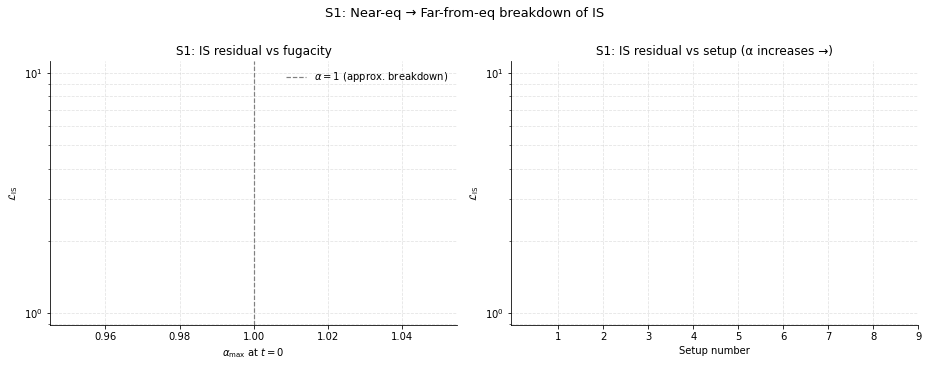

In [3]:
# S1: Plot the breakdown curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: L_IS vs alpha_max
ax = axes[0]
valid = ~np.isnan(L_IS_arr)
ax.semilogy(alpha_max_arr[valid], L_IS_arr[valid],
            'o-', lw=2, markersize=8, color='firebrick')
ax.axvline(1.0, color='gray', ls='--', lw=1.2,
           label=r'$\alpha = 1$ (approx. breakdown)')
ax.set_xlabel(r'$\alpha_{\rm max}$ at $t=0$')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S1: IS residual vs fugacity')
ax.legend(frameon=False)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Right: L_IS vs setup number, with alpha labels
ax = axes[1]
setups = np.arange(1, 10)
ax.semilogy(setups[valid], L_IS_arr[valid],
            's-', lw=2, markersize=8, color='steelblue')
for i, (s, a, l) in enumerate(zip(setups[valid],
                                   alpha_max_arr[valid],
                                   L_IS_arr[valid])):
    ax.annotate(f'  α={a:.2f}', (s, l), fontsize=8, va='center')
ax.set_xlabel('Setup number')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S1: IS residual vs setup (α increases →)')
ax.set_xticks(setups)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S1: Near-eq → Far-from-eq breakdown of IS', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Power-law fit for large alpha
if valid.sum() >= 4:
    from scipy.stats import linregress
    log_a = np.log10(alpha_max_arr[valid])
    log_L = np.log10(L_IS_arr[valid])
    slope, intercept, r, _, _ = linregress(log_a, log_L)
    print(f"Power-law fit: L_IS ~ alpha^{slope:.2f}  (R²={r**2:.3f})")
    print(f"Interpretation: IS residual grows as alpha^{slope:.1f} far from equilibrium.")


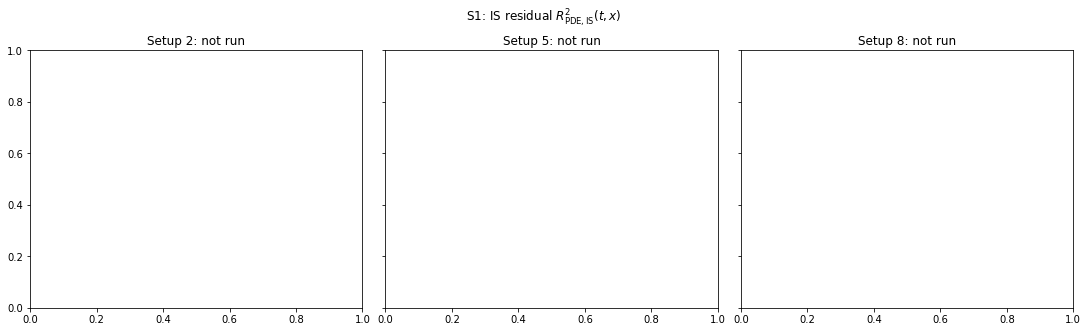

In [4]:
# S1: Residual heatmaps for 3 representative setups

show_setups = [2, 5, 8]   # near-eq, intermediate, far-from-eq

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5),
                         sharey=True, constrained_layout=True)

for ax, s in zip(axes, show_setups):
    if s not in res_cache:
        ax.set_title(f'Setup {s}: not run')
        continue
    R2 = res_cache[s]["R2"]
    t_s = res_cache[s]["res"]["t"]
    x_s = res_cache[s]["res"]["xc"]
    R2_clip = np.maximum(R2, 1e-32)
    im = ax.pcolormesh(x_s, t_s, R2_clip,
                       shading='auto', cmap='inferno',
                       norm=LogNorm(vmin=R2_clip.min(), vmax=R2_clip.max()))
    ax.set_title(f'Setup {s}  (α_max={res_cache[s]["res"]["alpha"].max():.2f})')
    ax.set_xlabel(r'$x$ [GeV$^{-1}$]')
    if ax is axes[0]: ax.set_ylabel(r'$t$ [GeV$^{-1}$]')
    ax.text(0.03, 0.96, f'$\mathcal{{L}}={res_cache[s]["L_IS"]:.2e}$',
            transform=ax.transAxes, fontsize=9, ha='left', va='top',
            bbox=dict(fc='white', alpha=0.8, ec='none', pad=3))
    fig.colorbar(im, ax=ax, orientation='horizontal',
                 fraction=0.046, pad=0.12,
                 ticks=LogLocator(numticks=3))

plt.suptitle(r'S1: IS residual $R^2_{\rm PDE,IS}(t,x)$', fontsize=12)
plt.show()


---
## S2 — Characteristic Velocity c_ch Sensitivity

**Question:** How does the IS residual L_IS depend on the choice of
characteristic speed c_ch?

The BDNK solution is **completely independent** of c_ch — it is a frame
choice in the IS decomposition only. However, c_ch controls:
- λ = σ/c_ch²   (the IS λ parameter)
- τ_J = λ/σ = 1/c_ch²   (in units of 1/σ)
- The matching correction n_IS = n_BDNK + λT·∂_t α

So c_ch measures how much the IS density differs from the BDNK density
and how fast the IS current relaxes. There should be an optimal c_ch
that minimises the mismatch, and this optimal value should be
frame-invariant in the near-equilibrium limit.

**Physical intuition:** c_ch = c_s (speed of sound) is the natural
physical scale. For QCD plasma, c_s ~ 1/√3 ≈ 0.577.


In [5]:
# S2: Vary c_ch for 3 setups

cch_vals   = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95])
test_setups = [2, 5, 8]   # near-eq, intermediate, far-from-eq
c_sound    = 1.0/np.sqrt(3)   # QCD conformal speed of sound

L_IS_cch = {s: [] for s in test_setups}

print("S2: Sweeping c_ch...")
for s in test_setups:
    for cch_v in cch_vals:
        try:
            res_v = run_bdnk(s, cch_override=cch_v, Nt_snap=60)
            n_IS_v, J_IS_v = apply_matching(res_v)
            _, L_v = compute_IS_residual(res_v, n_IS_v, J_IS_v)
            L_IS_cch[s].append(L_v)
        except Exception as e:
            L_IS_cch[s].append(np.nan)
    print(f"  setup {s} done,  best c_ch={cch_vals[np.nanargmin(L_IS_cch[s])]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_s = ['steelblue', 'darkorange', 'firebrick']

# Left: L_IS vs c_ch
ax = axes[0]
for s, col in zip(test_setups, colors_s):
    arr = np.array(L_IS_cch[s])
    ax.semilogy(cch_vals, arr, 'o-', lw=2, markersize=6,
                color=col, label=f'Setup {s}  (α_max≈{alpha_max_arr[s-1]:.2f})')
ax.axvline(c_sound, color='gray', ls='--', lw=1.5,
           label=f'$c_s=1/\\sqrt{{3}}={c_sound:.3f}$')
ax.set_xlabel(r'$c_{\rm ch}$')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S2: IS residual vs characteristic speed')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Right: normalised L_IS / L_IS(c_ch=0.5) to compare shapes
ax = axes[1]
for s, col in zip(test_setups, colors_s):
    arr = np.array(L_IS_cch[s])
    ref = arr[cch_vals == 0.5][0] if 0.5 in cch_vals else arr[4]
    ax.semilogy(cch_vals, arr/ref, 'o-', lw=2, markersize=6,
                color=col, label=f'Setup {s}')
ax.axhline(1.0, color='gray', ls='--', lw=1, label='c_ch=0.5 reference')
ax.axvline(c_sound, color='gray', ls=':', lw=1.5)
ax.set_xlabel(r'$c_{\rm ch}$')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS} / \mathcal{L}_{\rm IS}(c_{\rm ch}=0.5)$')
ax.set_title('S2: Normalised residual (shape comparison)')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S2: IS frame dependence via c_ch', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


S2: Sweeping c_ch...


ValueError: All-NaN slice encountered

---
## S3 — Transport Coefficient Magnitude C_B

**Question:** How sensitive is the IS matching to the overall scale of σ?

C_B sets the magnitude of σ(α, T). In RTA, C_B = 1/(4π) ≈ 0.0796.
The existing notebook already varies C_B linearly across setups.
Here we hold the setup (gradient strength) fixed and vary C_B,
to ask: *can we choose C_B to compensate for the IS–BDNK mismatch?*

**Physical intuition:** Larger C_B → larger σ → faster diffusion →
shorter τ_J. The IS and BDNK theories will agree on the diffusion rate
if and only if τ_J is correctly matched to the gradient scale.


In [ ]:
# S3: Vary C_B for 3 setups

CB_vals    = np.linspace(1/(4*np.pi), 0.45, 12)
L_IS_CB    = {s: [] for s in test_setups}

print("S3: Sweeping C_B...")
for s in test_setups:
    for CB_v in CB_vals:
        try:
            res_v = run_bdnk(s, C_B_override=CB_v, Nt_snap=60)
            n_IS_v, J_IS_v = apply_matching(res_v)
            _, L_v = compute_IS_residual(res_v, n_IS_v, J_IS_v, C_B_eval=CB_v)
            L_IS_CB[s].append(L_v)
        except Exception as e:
            L_IS_CB[s].append(np.nan)
    print(f"  setup {s} done")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: L_IS vs C_B
ax = axes[0]
for s, col in zip(test_setups, colors_s):
    ax.semilogy(CB_vals, np.array(L_IS_CB[s]), 'o-', lw=2, markersize=6,
                color=col, label=f'Setup {s}')
ax.axvline(1/(4*np.pi), color='gray', ls='--', lw=1.5,
           label=r'$C_B = 1/(4\pi)$  (RTA)')
ax.axvline(0.4, color='gray', ls=':', lw=1.5, label='$C_B = 0.4$')
ax.set_xlabel(r'$C_B$')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S3: IS residual vs $C_B$')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Right: sigma(alpha) shape for different C_B
ax = axes[1]
alpha_plot = np.linspace(0.01, 5.0, 300)
CB_plot    = [1/(4*np.pi), 0.1, 0.2, 0.3, 0.4]
cmap_CB    = plt.cm.viridis(np.linspace(0.15, 0.85, len(CB_plot)))
for CB_p, col_p in zip(CB_plot, cmap_CB):
    sig_p = sigma_of(alpha_plot, T_val*np.ones_like(alpha_plot), CB_p)
    ax.semilogy(alpha_plot, sig_p, lw=2, color=col_p,
                label=f'$C_B={CB_p:.3f}$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\sigma(\alpha, T)$  [GeV]')
ax.set_title(r'S3: $\sigma(\alpha)$ for different $C_B$')
ax.legend(frameon=False, fontsize=8)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S3: Transport coefficient magnitude sensitivity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## S4 — Relaxation Time τ_J Sensitivity

**Question:** Can the IS–BDNK mismatch be reduced by rescaling τ_J
independently of σ?

In RTA, τ_J = 12σT/n is fixed once σ is known. But IS is more general:
one can choose τ_J independently. Here we multiply τ_J by a factor
τ_mult ∈ [0.01, 100] and ask which τ_mult minimises L_IS.

- τ_mult → 0: Fick limit (J relaxes instantaneously → J = −σT∂_xα)
- τ_mult = 1: RTA value
- τ_mult → ∞: J barely relaxes (frozen initial condition)

**Expected:** An optimal τ_mult_opt(α) that decreases toward 1 as
α → 0 (near-equilibrium) and diverges (no τ_J can save IS) at large α.


In [ ]:
# S4: Vary tau_J multiplier

tau_mults  = np.logspace(-2, 2, 20)   # 0.01 to 100
L_IS_tau   = {s: [] for s in test_setups}

# Reuse the already-computed BDNK solutions (no re-simulation needed)
print("S4: Sweeping tau_J multiplier...")
for s in test_setups:
    if s not in res_cache:
        print(f"  setup {s}: not in cache, skipping")
        continue
    c = res_cache[s]
    for tm in tau_mults:
        try:
            _, L_v = compute_IS_residual(
                c["res"], c["n_IS"], c["J_IS"], tau_mult=tm)
            L_IS_tau[s].append(L_v)
        except Exception as e:
            L_IS_tau[s].append(np.nan)
    opt_idx = np.nanargmin(L_IS_tau[s])
    print(f"  setup {s}: optimal tau_mult={tau_mults[opt_idx]:.3f}, "
          f"L_IS_opt={L_IS_tau[s][opt_idx]:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for s, col in zip(test_setups, colors_s):
    if s not in L_IS_tau or len(L_IS_tau[s]) == 0: continue
    arr = np.array(L_IS_tau[s])
    ax.loglog(tau_mults, arr, 'o-', lw=2, markersize=5,
              color=col, label=f'Setup {s}  (α_max≈{alpha_max_arr[s-1]:.2f})')
    opt = np.nanargmin(arr)
    ax.axvline(tau_mults[opt], color=col, ls=':', lw=1.2, alpha=0.6)
ax.axvline(1.0, color='k', ls='--', lw=1.5, label='τ_mult=1  (RTA)')
ax.set_xlabel(r'$\tau_{\rm mult}$ (multiplier on $\tau_J$)')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S4: IS residual vs τ_J scaling')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Right: optimal tau_mult vs alpha
ax = axes[1]
opt_taus, opt_alphas = [], []
for s in range(1, 10):
    if s not in res_cache or s not in L_IS_tau: continue
    arr = np.array(L_IS_tau[s])
    if len(arr) == 0: continue
    opt_idx = np.nanargmin(arr)
    opt_taus.append(tau_mults[opt_idx])
    opt_alphas.append(alpha_max_arr[s-1])
ax.semilogx(opt_alphas, opt_taus, 'o-', lw=2, markersize=8, color='purple')
ax.axhline(1.0, color='gray', ls='--', lw=1.2, label='RTA value')
ax.axvline(1.0, color='gray', ls=':', lw=1.2, label='α=1')
ax.set_xlabel(r'$\alpha_{\rm max}$')
ax.set_ylabel(r'$\tau_{\rm mult}^{\rm opt}$')
ax.set_title('S4: Optimal τ_J multiplier vs α')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S4: Relaxation time sensitivity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## S5 — Gradient Strength vs L_IS: Power-law Breakdown

**Question:** Is there a quantitative relationship between the gradient
strength of the BDNK solution and the IS residual?

We define the gradient strength at each point as
|∂_x α|, and compute its maximum over the entire (t, x) domain.
Then we correlate this with L_IS across setups.

**Expected:** A power-law L_IS ~ (max |∂_x α|)^k, with k ~ 2–4.
This would confirm that the IS–BDNK incompatibility is a genuine
far-from-equilibrium effect, not just a numerical artefact.


In [ ]:
# S5: Gradient strength vs L_IS

grad_maxes = []
L_IS_all   = []

for s in range(1, 10):
    if s not in res_cache: continue
    c = res_cache[s]
    alpha = c["res"]["alpha"]
    dx    = c["res"]["dx"]
    grad_x = np.abs(ddx(alpha, dx))
    grad_t = np.abs(ddt(alpha, c["res"]["t"]))
    grad_max = max(grad_x.max(), grad_t.max())
    grad_maxes.append(grad_max)
    L_IS_all.append(c["L_IS"])

grad_maxes = np.array(grad_maxes)
L_IS_all   = np.array(L_IS_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(grad_maxes, L_IS_all, 'o', markersize=9,
          color='firebrick', zorder=5)
for i, (g, l, s) in enumerate(zip(grad_maxes, L_IS_all,
                                   [k for k in res_cache.keys()])):
    ax.annotate(f' s{s}', (g, l), fontsize=8)

# Power-law fit
from scipy.stats import linregress
log_g = np.log10(grad_maxes)
log_l = np.log10(L_IS_all)
slope, intercept, r, _, _ = linregress(log_g, log_l)
g_fit = np.logspace(log_g.min(), log_g.max(), 100)
ax.loglog(g_fit, 10**intercept * g_fit**slope, 'k--', lw=1.5,
          label=f'Fit: $\\propto |\\partial_x\\alpha|^{{{slope:.1f}}}$ '
                f'($R^2={r**2:.3f}$)')
ax.set_xlabel(r'$\max|\partial_x \alpha|$  [GeV]')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S5: Power-law breakdown')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Right: cumulative distribution of residuals
ax = axes[1]
for i, s in enumerate([2, 5, 8]):
    if s not in res_cache: continue
    R2_flat = res_cache[s]["R2"].flatten()
    sorted_R2 = np.sort(R2_flat)
    cdf = np.arange(1, len(sorted_R2)+1) / len(sorted_R2)
    ax.loglog(sorted_R2, 1-cdf, lw=2,
              color=colors_s[i],
              label=f'Setup {s}  (α_max≈{alpha_max_arr[s-1]:.2f})')
ax.set_xlabel(r'$R^2_{\rm PDE,IS}$')
ax.set_ylabel(r'CCDF  $P(R^2 > r)$')
ax.set_title('S5: Tail distribution of residuals')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S5: Gradient-residual power law', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print(f"Power-law exponent: L_IS ~ |∂_x α|^{slope:.2f}")


---
## S6 — Frame Invariance: J^μ is Conserved Across Theories

**Question:** The matching conditions are designed so that J^μ_IS = J^μ_BDNK
*by construction*. But n_IS ≠ n_BDNK. How large is the density difference,
and does it grow with α?

The density difference Δn = n_IS - n_BDNK = λ·T·γ·(∂_t + v∂_x)α is the
frame correction. For v=0 and small gradients: Δn ~ λ·T·∂_t α.
Since λ = σ/c_ch², this correction is proportional to σ·T/c_ch², which
is large for large α (large σ) or small c_ch.


In [ ]:
# S6: Frame invariance — density difference and J^mu conservation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Relative density difference |n_IS - n_BDNK| / n_BDNK vs alpha
rel_diff_by_setup = []
alpha_by_setup    = []

for s in range(1, 10):
    if s not in res_cache: continue
    c = res_cache[s]
    n_B   = c["res"]["n"]
    n_IS  = c["n_IS"]
    rel   = np.abs(n_IS - n_B) / (np.abs(n_B) + 1e-12)
    rel_diff_by_setup.append(rel.mean())
    alpha_by_setup.append(c["res"]["alpha"].max())

ax = axes[0]
ax.semilogy(alpha_by_setup, rel_diff_by_setup,
            'o-', lw=2, markersize=8, color='darkorange')
ax.axvline(1.0, color='gray', ls='--', lw=1.2)
ax.set_xlabel(r'$\alpha_{\rm max}$')
ax.set_ylabel(r'$\langle|n_{\rm IS}-n_{\rm BDNK}|/n_{\rm BDNK}\rangle$')
ax.set_title('S6: Relative density difference')
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Panel 2: n_IS vs n_BDNK scatter for setup 5
s_show = 5
if s_show in res_cache:
    c = res_cache[s_show]
    n_B   = c["res"]["n"].flatten()
    n_IS  = c["n_IS"].flatten()
    lims  = [min(n_B.min(), n_IS.min())*0.95,
             max(n_B.max(), n_IS.max())*1.05]
    axes[1].scatter(n_B, n_IS, s=1, alpha=0.2, color='steelblue')
    axes[1].plot(lims, lims, 'k--', lw=1.2, label='n_IS = n_BDNK')
    axes[1].set_xlabel(r'$n_{\rm BDNK}$  [GeV$^3$]')
    axes[1].set_ylabel(r'$n_{\rm IS}$  [GeV$^3$]')
    axes[1].set_title(f'S6: Density comparison (setup {s_show})')
    axes[1].legend(frameon=False, fontsize=9)
    axes[1].grid(True, ls='--', alpha=0.35)
    for sp in ['top','right']: axes[1].spines[sp].set_visible(False)

# Panel 3: Verify J^mu conservation (charge integral)
ax = axes[2]
for s, col in zip([2, 5, 8], colors_s):
    if s not in res_cache: continue
    c    = res_cache[s]
    J0_B = c["res"]["J0"]          # BDNK J^0
    x_s  = c["res"]["xc"]
    t_s  = c["res"]["t"]
    # Charge = ∫ J^0 dx (in LRF, J^0 = n)
    Q_B = np.trapz(J0_B, x_s, axis=1)
    Q_0 = Q_B[0]
    ax.plot(t_s, (Q_B - Q_0)/np.abs(Q_0)*100, lw=2, color=col,
            label=f'Setup {s} (α={alpha_max_arr[s-1]:.2f})')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$t$ [GeV$^{-1}$]')
ax.set_ylabel(r'$(Q(t)-Q_0)/Q_0$ [%]')
ax.set_title('S6: Charge conservation in BDNK')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S6: Frame invariance and charge conservation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## S7 — Time Evolution of the IS Residual L_IS(t)

**Question:** Does the IS–BDNK mismatch grow or decay in time?
Is there an early-time transient from the initial condition?

We compute L_IS(t) = mean_x R²_IS(t, x) at each time slice,
showing the time profile of the mismatch.

**Expected behaviours:**
- Near-eq (small α): L_IS(t) decays → diffusion brings the system
  to equilibrium where IS and BDNK agree
- Far-from-eq (large α): L_IS(t) may peak early then decay, or stay large
- The early-time peak corresponds to the sharpest gradients in the IC


In [ ]:
# S7: Time evolution of L_IS(t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax_left  = axes[0]
ax_right = axes[1]

cmap_t = plt.cm.plasma(np.linspace(0.1, 0.9, 9))

for s in range(1, 10):
    if s not in res_cache: continue
    c     = res_cache[s]
    R2    = c["R2"]            # (Nt, Nx)
    t_s   = c["res"]["t"]
    L_t   = R2.mean(axis=1)   # mean over x at each t
    col   = cmap_t[s-1]

    ax_left.semilogy(t_s, L_t, lw=1.5, color=col,
                     label=f's{s} α={alpha_max_arr[s-1]:.2f}')
    ax_right.semilogy(t_s, L_t / L_t[1], lw=1.5, color=col,
                      label=f's{s}')

ax_left.set_xlabel(r'$t$ [GeV$^{-1}$]')
ax_left.set_ylabel(r'$\mathcal{L}_{\rm IS}(t)$  [mean over $x$]')
ax_left.set_title('S7: IS residual time profile')
ax_left.legend(frameon=False, fontsize=7, ncol=2)
ax_left.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax_left.spines[sp].set_visible(False)

ax_right.set_xlabel(r'$t$ [GeV$^{-1}$]')
ax_right.set_ylabel(r'$\mathcal{L}_{\rm IS}(t)/\mathcal{L}_{\rm IS}(t_1)$')
ax_right.set_title('S7: Normalised residual (relative to early time)')
ax_right.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax_right.spines[sp].set_visible(False)

plt.suptitle('S7: How does the IS mismatch evolve in time?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## S8 — Fick's Law Limit: Does J → −σT ∂_x α?

**Question:** In the long-time (equilibrium) limit, the IS current
should relax to the Fick value J_Fick = −σT ∂_x α₂. How far is the
matched current J_IS from this limit?

Define the Fick fraction:  F(t) = ⟨|J_IS - J_Fick|² / |J_Fick|²⟩_x

- F ~ 0: IS current is in the Fick (near-equilibrium) regime
- F ~ 1: IS current is as far from Fick as possible (far-from-eq)

**Expected:** F(t=0) is large, decays towards zero at late t
(system equilibrates). F at t=0 grows with α.


In [ ]:
# S8: Fick's law deviation

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Fick fraction vs time for 3 setups
ax = axes[0]
for s, col in zip([2, 5, 8], colors_s):
    if s not in res_cache: continue
    c     = res_cache[s]
    n_IS  = c["n_IS"]
    J_IS  = c["J_IS"]
    T_s   = c["res"]["T"]
    dx    = c["res"]["dx"]
    t_s   = c["res"]["t"]

    alpha2   = alpha_from_n(np.maximum(n_IS, 1e-12), T_s)
    alpha2_x = ddx(alpha2, dx)
    J_Fick   = -c["res"]["sigma"] * T_s * alpha2_x

    # Use BDNK sigma (sigma evaluated at alpha2) for Fick estimate
    sigma2 = sigma_of(alpha2, T_s, c["res"]["C_B"])
    J_Fick2 = -sigma2 * T_s * alpha2_x

    F_t = np.mean((J_IS - J_Fick2)**2, axis=1) / (np.mean(J_Fick2**2, axis=1) + 1e-12)
    ax.semilogy(t_s, F_t, lw=2, color=col,
                label=f'Setup {s}  (α_max≈{alpha_max_arr[s-1]:.2f})')

ax.set_xlabel(r'$t$ [GeV$^{-1}$]')
ax.set_ylabel(r'$\langle|J_{\rm IS} - J_{\rm Fick}|^2/|J_{\rm Fick}|^2\rangle_x$')
ax.set_title("S8: Deviation from Fick's law vs time")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Right: Fick fraction at t=0 vs alpha
ax = axes[1]
F0_vals, alpha_vals = [], []
for s in range(1, 10):
    if s not in res_cache: continue
    c     = res_cache[s]
    n_IS  = c["n_IS"]
    J_IS  = c["J_IS"]
    T_s   = c["res"]["T"]
    dx    = c["res"]["dx"]

    alpha2  = alpha_from_n(np.maximum(n_IS[0], 1e-12), T_s[0])
    alpha2_x = ddx(alpha2[np.newaxis], dx)[0]
    sigma2  = sigma_of(alpha2, T_s[0], c["res"]["C_B"])
    J_Fick2 = -sigma2 * T_s[0] * alpha2_x

    F0 = np.mean((J_IS[0] - J_Fick2)**2) / (np.mean(J_Fick2**2) + 1e-12)
    F0_vals.append(F0)
    alpha_vals.append(c["res"]["alpha"].max())

ax.semilogy(alpha_vals, F0_vals, 'o-', lw=2, markersize=8, color='darkorange')
ax.axvline(1.0, color='gray', ls='--', lw=1.2, label='α=1')
ax.set_xlabel(r'$\alpha_{\rm max}$')
ax.set_ylabel(r'Fick deviation at $t=0$')
ax.set_title("S8: Initial Fick deviation vs α")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle("S8: Fick's law relaxation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## S9 — Phase Diagram: L_IS(α, c_ch)

**Question:** What is the joint dependence of the IS residual on both
the fugacity α (gradient strength) and the characteristic speed c_ch?

This produces a 2D heat map — the IS–BDNK compatibility "phase diagram" —
showing which regions of (α, c_ch) space allow IS to reproduce BDNK.

**Physical intuition:**
- The top-left region (small α, any c_ch) should be dark (low L_IS)
- The bottom-right region (large α, large c_ch) should be bright (high L_IS)
- The transition boundary marks where IS breaks down


In [ ]:
# S9: Phase diagram L_IS(α_max, c_ch)
# Note: this runs ~5x5=25 simulations — may take a few minutes

alpha_setups = [2, 4, 5, 7, 9]    # representative setups (increasing α)
cch_grid     = [0.2, 0.4, 0.6, 0.8, 0.95]

alpha_labels = [f"{alpha_max_arr[s-1]:.2f}" for s in alpha_setups]
L_IS_2D      = np.full((len(alpha_setups), len(cch_grid)), np.nan)

print("S9: Building phase diagram...")
for i, s in enumerate(alpha_setups):
    for j, cch_v in enumerate(cch_grid):
        try:
            res_v = run_bdnk(s, cch_override=cch_v, Nt_snap=50)
            n_IS_v, J_IS_v = apply_matching(res_v)
            _, L_v = compute_IS_residual(res_v, n_IS_v, J_IS_v)
            L_IS_2D[i, j] = L_v
            print(f"  s={s}, c_ch={cch_v:.2f}: L_IS={L_v:.3e}")
        except Exception as e:
            print(f"  s={s}, c_ch={cch_v:.2f}: ERROR {e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D heatmap
ax = axes[0]
im = ax.imshow(L_IS_2D, aspect='auto', cmap='inferno',
               norm=LogNorm(vmin=np.nanmin(L_IS_2D[L_IS_2D>0]),
                            vmax=np.nanmax(L_IS_2D)),
               origin='lower')
ax.set_xticks(np.arange(len(cch_grid)))
ax.set_xticklabels([f'{c:.2f}' for c in cch_grid])
ax.set_yticks(np.arange(len(alpha_setups)))
ax.set_yticklabels([f'{a}' for a in alpha_labels])
ax.set_xlabel(r'$c_{\rm ch}$')
ax.set_ylabel(r'$\alpha_{\rm max}$')
ax.set_title('S9: Phase diagram $\mathcal{L}_{\rm IS}(\alpha, c_{\rm ch})$')
plt.colorbar(im, ax=ax, label=r'$\mathcal{L}_{\rm IS}$')

# Contour overlaid
try:
    cs = ax.contour(L_IS_2D, levels=3, colors='white', linewidths=0.8, alpha=0.6)
    ax.clabel(cs, fmt='%.1e', fontsize=8)
except:
    pass

# Right: slices through the phase diagram
ax = axes[1]
cmap_pd = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(cch_grid)))
for j, (cch_v, col_pd) in enumerate(zip(cch_grid, cmap_pd)):
    valid_rows = ~np.isnan(L_IS_2D[:, j])
    if valid_rows.sum() < 2: continue
    al_v = [alpha_max_arr[s-1] for s in np.array(alpha_setups)[valid_rows]]
    li_v = L_IS_2D[valid_rows, j]
    ax.semilogy(al_v, li_v, 'o-', lw=2, markersize=6,
                color=col_pd, label=f'$c_{{\\rm ch}}={cch_v:.2f}$')

ax.axvline(1.0, color='gray', ls='--', lw=1.2, label='α=1')
ax.set_xlabel(r'$\alpha_{\rm max}$')
ax.set_ylabel(r'$\mathcal{L}_{\rm IS}$')
ax.set_title('S9: L_IS vs α for different c_ch')
ax.legend(frameon=False, fontsize=8)
ax.grid(True, which='both', ls='--', alpha=0.35)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('S9: IS–BDNK compatibility phase diagram', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## Summary Table

After running all studies, this cell collects key numbers into a summary.


In [ ]:
# Summary

print("=" * 70)
print("IS–BDNK ANALYSIS SUMMARY")
print("=" * 70)
print()
print("S1: Near-eq → far-from-eq sweep")
for s in range(1, 10):
    if s not in res_cache: continue
    print(f"  Setup {s}:  alpha_max={alpha_max_arr[s-1]:.3f}  "
          f"L_IS={res_cache[s]['L_IS']:.3e}")
print()

try:
    print(f"S5: Power-law fit: L_IS ~ alpha^{slope:.2f}  (R²={r**2:.3f})")
    print(f"    → IS residual grows as alpha^{slope:.1f} far from equilibrium")
    print()
except: pass

print("S2: Optimal c_ch (approximate):")
for s in test_setups:
    if s not in L_IS_cch or len(L_IS_cch[s]) == 0: continue
    arr = np.array(L_IS_cch[s])
    opt = cch_vals[np.nanargmin(arr)]
    print(f"  Setup {s}:  c_ch_opt ~ {opt:.2f}  "
          f"(vs c_s=1/sqrt(3)={1/3**0.5:.3f})")
print()

print("S4: Optimal tau_mult (approximate):")
for s in test_setups:
    if s not in L_IS_tau or len(L_IS_tau[s]) == 0: continue
    arr = np.array(L_IS_tau[s])
    opt = tau_mults[np.nanargmin(arr)]
    print(f"  Setup {s}:  tau_mult_opt ~ {opt:.3f}  (vs RTA = 1.0)")
print()

print("S6: Relative density difference |n_IS - n_BDNK| / n_BDNK:")
for i, (a, d) in enumerate(zip(alpha_by_setup, rel_diff_by_setup)):
    print(f"  alpha_max={a:.3f}: {d*100:.3f}%")
print()
print("=" * 70)
